In [13]:
import pandas as pd

df = pd.read_csv("../data/fake_job_postings.csv")

print("Shape:", df.shape)

df.head()

Shape: (17880, 18)


,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [14]:
print(df.shape)

(17880, 18)


In [15]:
import sys
print(sys.executable)


c:\Users\Nikhil\venv\Scripts\python.exe


In [16]:
print(df.columns)


Index(['job_id', 'title', 'location', 'department', 'salary_range',
       'company_profile', 'description', 'requirements', 'benefits',
       'telecommuting', 'has_company_logo', 'has_questions', 'employment_type',
       'required_experience', 'required_education', 'industry', 'function',
       'fraudulent'],
      dtype='str')


0 = Real Job
1 = Fake Job

In [17]:
df["fraudulent"].value_counts()

fraudulent
0    17014
1      866
Name: count, dtype: int64

In [18]:
df.isnull().sum()

job_id                     0
title                      0
location                 346
department             11547
salary_range           15012
company_profile         3308
description                1
requirements            2696
benefits                7212
telecommuting              0
has_company_logo           0
has_questions              0
employment_type         3471
required_experience     7050
required_education      8105
industry                4903
function                6455
fraudulent                 0
dtype: int64

In [19]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   job_id               17880 non-null  int64
 1   title                17880 non-null  str  
 2   location             17534 non-null  str  
 3   department           6333 non-null   str  
 4   salary_range         2868 non-null   str  
 5   company_profile      14572 non-null  str  
 6   description          17879 non-null  str  
 7   requirements         15184 non-null  str  
 8   benefits             10668 non-null  str  
 9   telecommuting        17880 non-null  int64
 10  has_company_logo     17880 non-null  int64
 11  has_questions        17880 non-null  int64
 12  employment_type      14409 non-null  str  
 13  required_experience  10830 non-null  str  
 14  required_education   9775 non-null   str  
 15  industry             12977 non-null  str  
 16  function             11425 non-nu

In [20]:
df["fraudulent"].value_counts(normalize=True) * 100

fraudulent
0    95.1566
1     4.8434
Name: proportion, dtype: float64

In [21]:
df.isnull().sum()

job_id                     0
title                      0
location                 346
department             11547
salary_range           15012
company_profile         3308
description                1
requirements            2696
benefits                7212
telecommuting              0
has_company_logo           0
has_questions              0
employment_type         3471
required_experience     7050
required_education      8105
industry                4903
function                6455
fraudulent                 0
dtype: int64

In [22]:
df.groupby("fraudulent")["has_company_logo"].mean()

fraudulent
0    0.819149
1    0.326790
Name: has_company_logo, dtype: float64

In [23]:
df.groupby("fraudulent")["has_questions"].mean()

fraudulent
0    0.502057
1    0.288684
Name: has_questions, dtype: float64

In [24]:
df.groupby("fraudulent")["telecommuting"].mean()

fraudulent
0    0.041319
1    0.073903
Name: telecommuting, dtype: float64

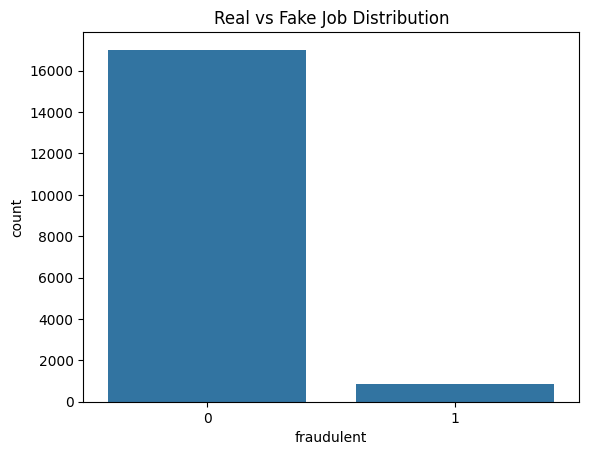

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="fraudulent", data=df)
plt.title("Real vs Fake Job Distribution")
plt.show()

FEATURE ENGENEERING

In [26]:
df["text"] = (
    df["title"].fillna("") + " " +
    df["company_profile"].fillna("") + " " +
    df["description"].fillna("") + " " +
    df["requirements"].fillna("")
)

Make sure the combined text looks reasonable.

In [27]:
df["text"].head()

0    Marketing Intern We're Food52, and we've creat...
1    Customer Service - Cloud Video Production 90 S...
2    Commissioning Machinery Assistant (CMA) Valor ...
3    Account Executive - Washington DC Our passion ...
4    Bill Review Manager SpotSource Solutions LLC i...
Name: text, dtype: str

In [28]:
from sklearn.model_selection import train_test_split

X = df["text"]
y = df["fraudulent"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Convert Text to Numbers (TF-IDF)

In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

Logistic Regression

In [30]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train_tfidf, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [31]:
y_pred = model.predict(X_test_tfidf)
y_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(3576,))

Evaluate

In [32]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99      3403
           1       1.00      0.47      0.64       173

    accuracy                           0.97      3576
   macro avg       0.99      0.74      0.81      3576
weighted avg       0.98      0.97      0.97      3576



IMPROVING THE TRAINING BECAUSE OF THE LOW RECALL

In [33]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

model.fit(X_train_tfidf, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Defaul

In [34]:
y_pred = model.predict(X_test_tfidf)

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.97      0.98      3403
           1       0.62      0.88      0.73       173

    accuracy                           0.97      3576
   macro avg       0.81      0.93      0.86      3576
weighted avg       0.98      0.97      0.97      3576



In [35]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[3310   93]
 [  20  153]]


inspect what words the model learned

In [36]:
feature_names = tfidf.get_feature_names_out()

coefficients = model.coef_[0]

top_fake = sorted(
    zip(coefficients, feature_names),
    reverse=True
)[:20]

top_fake

[(np.float64(5.197855129383016), 'link'),
 (np.float64(4.440483218476361), 'aptitude'),
 (np.float64(4.115837544345345), 'entry'),
 (np.float64(3.7401055099853666), 'money'),
 (np.float64(3.4365328487933655), 'financing'),
 (np.float64(3.23289529345526), 'earn'),
 (np.float64(3.1653736059636075), 'clerk'),
 (np.float64(2.9849794048539953), 'administrative'),
 (np.float64(2.913112194913574), 'gas'),
 (np.float64(2.8999858318348806), 'optical'),
 (np.float64(2.8425387796206265), 'requirements'),
 (np.float64(2.818992527859084), 'offshore'),
 (np.float64(2.817534748308882), 'engineering'),
 (np.float64(2.765662458613091), 'hospital'),
 (np.float64(2.7498514652894563), 'subsea'),
 (np.float64(2.7321164459191887), 'oil'),
 (np.float64(2.702330924498221), 'cash'),
 (np.float64(2.627871363569582), 'assistant'),
 (np.float64(2.6088923589648543), 'accountant'),
 (np.float64(2.5942663641564057), 'aker')]

SAVING THE TRAINING

In [37]:
import joblib

joblib.dump(model, "../models/logistic_fraud_detector.pkl")
joblib.dump(tfidf, "../models/tfidf_vectorizer.pkl")

['../models/tfidf_vectorizer.pkl']

In [38]:
import sys
print(sys.executable)

c:\Users\Nikhil\venv\Scripts\python.exe


In [39]:
import sys
!{sys.executable} -m pip show xgboost

Name: xgboost
Version: 3.2.0
Summary: XGBoost Python Package
Home-page: 
Author: 
Author-email: Hyunsu Cho <chohyu01@cs.washington.edu>, Jiaming Yuan <jm.yuan@outlook.com>
License: Apache-2.0
Location: c:\Users\Nikhil\venv\Lib\site-packages
Requires: numpy, scipy
Required-by: 


In [40]:
import sys
!{sys.executable} -m pip install xgboost

In [41]:
from xgboost import XGBClassifier

In [42]:
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)

xgb_model.fit(X_train_tfidf, y_train)

y_pred_xgb = xgb_model.predict(X_test_tfidf)

In [43]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred_xgb))

cm = confusion_matrix(y_test, y_pred_xgb)
print(cm)

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3403
           1       1.00      0.63      0.77       173

    accuracy                           0.98      3576
   macro avg       0.99      0.82      0.88      3576
weighted avg       0.98      0.98      0.98      3576

[[3403    0]
 [  64  109]]


In [44]:
import joblib

joblib.dump(xgb_model, "../models/xgboost_fraud_detector.pkl")

['../models/xgboost_fraud_detector.pkl']

In [45]:
import sys
print(sys.executable)

c:\Users\Nikhil\venv\Scripts\python.exe


version 3 

In [46]:
structured_features = df[
    [
        "has_company_logo",
        "has_questions",
        "telecommuting"
    ]
]

structured_features.head()

,has_company_logo,has_questions,telecommuting
0,1,0,0
1,1,0,0
2,1,0,0
3,1,0,0
4,1,1,0


In [47]:
X_train_struct = structured_features.loc[
    X_train.index
]

X_test_struct = structured_features.loc[
    X_test.index
]

In [48]:
from scipy.sparse import hstack

X_train_final = hstack(
    [X_train_tfidf, X_train_struct]
)

X_test_final = hstack(
    [X_test_tfidf, X_test_struct]
)

In [49]:
print(X_train_final.shape)

print(X_test_final.shape)

(14304, 5003)
(3576, 5003)


The extra 3 columns are:

has_company_logo
has_questions
telecommuting

In [50]:
from xgboost import XGBClassifier

xgb_model_v3 = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)

xgb_model_v3.fit(
    X_train_final,
    y_train
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [51]:
y_pred_v3 = xgb_model_v3.predict(
    X_test_final
)

In [52]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

print(
    classification_report(
        y_test,
        y_pred_v3
    )
)

print(
    confusion_matrix(
        y_test,
        y_pred_v3
    )
)

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3403
           1       0.98      0.69      0.81       173

    accuracy                           0.98      3576
   macro avg       0.98      0.85      0.90      3576
weighted avg       0.98      0.98      0.98      3576

[[3401    2]
 [  53  120]]


In [53]:
from sklearn.linear_model import LogisticRegression

logistic_v3 = LogisticRegression(
    class_weight="balanced",
    max_iter=1000
)

logistic_v3.fit(
    X_train_final,
    y_train
)

y_pred_log_v3 = logistic_v3.predict(
    X_test_final
)

In [54]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_log_v3
    )
)

              precision    recall  f1-score   support

           0       0.99      0.96      0.98      3403
           1       0.54      0.90      0.68       173

    accuracy                           0.96      3576
   macro avg       0.77      0.93      0.83      3576
weighted avg       0.97      0.96      0.96      3576



In [55]:
joblib.dump(logistic_v3,
            "../models/logistic_structured_v3.pkl")

joblib.dump(xgb_model_v3,
            "../models/xgboost_structured_v3.pkl")

['../models/xgboost_structured_v3.pkl']

Version 4 — Trust Score Engine
Goal

Generate a score from 0–100 that estimates how trustworthy a job posting is.

Example:

Trust Score: 87/100

Company Logo: +20
Screening Questions: +15
Not Remote: +10
ML Prediction Confidence: +25
Verified Company Website: +17

Result:
Likely Genuine

In [56]:
def calculate_trust_score(
    has_logo,
    has_questions,
    telecommuting,
    fraud_probability
):
    
    score = 50

    if has_logo:
        score += 15

    if has_questions:
        score += 10

    if not telecommuting:
        score += 5

    score += int((1 - fraud_probability) * 20)

    return min(score,100)

Add Explanation System

In [57]:
has_logo = 1
has_questions = 0
telecommuting = 1
fraud_probability = 0.75

In [58]:
reasons = []

if not has_logo:
    reasons.append("Company logo missing")

if not has_questions:
    reasons.append("No screening questions")

if telecommuting:
    reasons.append("Remote position")

if fraud_probability > 0.7:
    reasons.append("Model confidence indicates risk")

print(reasons)

['No screening questions', 'Remote position', 'Model confidence indicates risk']


In [59]:
reasons = []

if not has_logo:
    reasons.append("⚠️ Company logo missing")

if not has_questions:
    reasons.append("⚠️ No screening questions")

if telecommuting:
    reasons.append("⚠️ Remote position")

if fraud_probability > 0.7:
    reasons.append("⚠️ Model confidence indicates elevated risk")

for r in reasons:
    print(r)

⚠️ No screening questions
⚠️ Remote position
⚠️ Model confidence indicates elevated risk


Then create the Trust Score function

In [60]:
def calculate_trust_score(
    has_logo,
    has_questions,
    telecommuting,
    fraud_probability
):

    score = 50

    if has_logo:
        score += 15

    if has_questions:
        score += 10

    if not telecommuting:
        score += 5

    score += int((1 - fraud_probability) * 20)

    return min(score, 100)

In [61]:
score = calculate_trust_score(
    has_logo=1,
    has_questions=0,
    telecommuting=1,
    fraud_probability=0.75
)

print(score)

70


Version 5 — DistilBERT Fraud Detection

In [62]:
!pip install transformers

In [63]:
from transformers import DistilBertTokenizer

tokenizer = DistilBertTokenizer.from_pretrained(
    "distilbert-base-uncased"
)

In [64]:
!pip install transformers datasets accelerate torch scikit-learn

In [65]:
import transformers
print(transformers.__version__)

5.12.0


In [66]:
from sklearn.model_selection import train_test_split

train_texts, test_texts, train_labels, test_labels = train_test_split(
    df["text"],
    df["fraudulent"],
    test_size=0.2,
    random_state=42,
    stratify=df["fraudulent"]
)

Tokenization

In [67]:
train_encodings = tokenizer(
    train_texts.tolist(),
    truncation=True,
    padding=True,
    max_length=256
)

test_encodings = tokenizer(
    test_texts.tolist(),
    truncation=True,
    padding=True,
    max_length=256
)

In [68]:
import torch
print(torch.__version__)

2.12.0+cpu


Create Dataset Class

In [69]:
import torch

class JobDataset(torch.utils.data.Dataset):

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):

        item = {
            key: torch.tensor(val[idx])
            for key, val in self.encodings.items()
        }

        item["labels"] = torch.tensor(
            self.labels.iloc[idx]
        )

        return item

    def __len__(self):
        return len(self.labels)

Create Datasets

In [84]:
train_dataset = JobDataset(
    train_encodings,
    train_labels
)

test_dataset = JobDataset(
    test_encodings,
    test_labels
)

Load DistilBERT Model

In [71]:
from transformers import DistilBertForSequenceClassification

model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [72]:
import torch

print(torch.__version__)
print(torch.__file__)

2.12.0+cpu
c:\Users\Nikhil\venv\Lib\site-packages\torch\__init__.py


Training Arguments

In [81]:
import transformers
print(transformers.__version__)

5.12.0


In [82]:
from transformers import TrainingArguments
help(TrainingArguments)

Help on class TrainingArguments in module transformers.training_args:

class TrainingArguments(builtins.object)
 |  TrainingArguments(
 |      output_dir: str | None = None,
 |      per_device_train_batch_size: int = 8,
 |      num_train_epochs: float = 3.0,
 |      max_steps: int = -1,
 |      learning_rate: float = 5e-05,
 |      lr_scheduler_type: transformers.trainer_utils.SchedulerType | str = 'linear',
 |      lr_scheduler_kwargs: dict | str | None = None,
 |      warmup_steps: float = 0,
 |      optim: transformers.training_args.OptimizerNames | str = 'adamw_torch_fused',
 |      optim_args: str | None = None,
 |      weight_decay: float = 0.0,
 |      adam_beta1: float = 0.9,
 |      adam_beta2: float = 0.999,
 |      adam_epsilon: float = 1e-08,
 |      optim_target_modules: None | str | list[str] = None,
 |      gradient_accumulation_steps: int = 1,
 |      average_tokens_across_devices: bool = True,
 |      max_grad_norm: float = 1.0,
 |      label_smoothing_factor: float = 

In [87]:
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_dir="./logs"
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Trainer

In [88]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)

trainer.train()

Epoch,Training Loss,Validation Loss
1,0.093075,0.066467
2,0.034224,0.053307
3,0.017950,0.057240


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

c:\Users\Nikhil\venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

c:\Users\Nikhil\venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=5364, training_loss=0.05641071232817761, metrics={'train_runtime': 19242.017, 'train_samples_per_second': 2.23, 'train_steps_per_second': 0.279, 'total_flos': 2842220505563136.0, 'train_loss': 0.05641071232817761, 'epoch': 3.0})

Predictions

In [89]:
predictions = trainer.predict(
    test_dataset
)

preds = predictions.predictions.argmax(
    axis=1
)

c:\Users\Nikhil\venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Evaluation

In [90]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

print(
    classification_report(
        test_labels,
        preds
    )
)

print(
    confusion_matrix(
        test_labels,
        preds
    )
)

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      3403
           1       0.91      0.86      0.88       173

    accuracy                           0.99      3576
   macro avg       0.95      0.93      0.94      3576
weighted avg       0.99      0.99      0.99      3576

[[3388   15]
 [  24  149]]


Save Model

In [91]:
model.save_pretrained(
    "../models/distilbert_v5"
)

tokenizer.save_pretrained(
    "../models/distilbert_v5"
)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('../models/distilbert_v5\\tokenizer_config.json',
 '../models/distilbert_v5\\tokenizer.json')

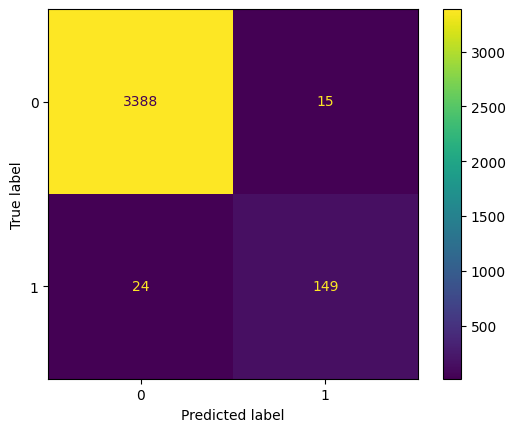

In [92]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(test_labels, preds)

ConfusionMatrixDisplay(cm).plot()

plt.show()